In [411]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from acm import NominalACM
import matplotlib.pyplot as plt
from build_moex_curve import build_moex_curve
from ruonia import load_ruonia_1m, build_ruonia_monthly
from run_acm_model import run_acm_model
from sklearn.decomposition import PCA
from numpy.linalg import inv
from statsmodels.tools.tools import add_constant

## Обозначения

Используем стандартные обозначения ACM и сразу связываем их с именами в коде.

| Математика | Смысл | Имя в `acm.py` |
|---|---|---|
| $y_t^{(n)}$ | доходность нулевого купона для срока $n$ месяцев | `curve`, `curve_monthly` |
| $p_t^{(n)} = - \frac{n}{12} y_t^{(n)}$ | лог-цена облигации | `log_prices` |
| $r_t^{(1)}$ | короткая ставка на один период | `short_rate_proxy` |
| $rx_{t+1}^{(n)}$ | excess return | `rx_m` |
| $X_t$ | вектор факторного состояния | `pc_factors_m` |
| $v_{t+1}$ | инновации VAR | `v` |
| $(\mu, \Phi, \Sigma)$ | параметры VAR(1) | `mu`, `phi`, `Sigma` |
| $(\beta, \beta^*)$ | loadings excess returns на shocks | `beta`, `beta_star` |
| $(\lambda_0, \lambda_1)$ | prices of risk | `lambda0`, `lambda1` |
| $(\delta_0, \delta_1)$ | short-rate equation | `delta0`, `delta1` |
| $(A_n, B_n)$ | affine coefficients | `A`, `B` |
| $y_t^{(n), RN}$ | risk-neutral yield | `rny` |
| $TP_t^{(n)}$ | term premium | `tp` |

Ниже идем ровно в том порядке, в котором код выполняется в `__init__`.


In [412]:
def tenor_columns(df: pd.DataFrame) -> list[str]:
    return sorted(
        [c for c in df.columns if re.fullmatch(r"M\d{3}", c)],
        key=lambda c: int(c[1:]),
    )

def to_pyacm_curve(curve_df: pd.DataFrame) -> pd.DataFrame:
    df = curve_df.copy()
    df["date"] = pd.to_datetime(df["month_end"])
    df = df.set_index("date").sort_index()

    cols = tenor_columns(df)
    yield_curve = df[cols].copy()
    yield_curve.columns = [int(c[1:]) for c in cols]
    yield_curve = np.log1p(yield_curve / 100.0)

    yield_curve.index.name = "date"
    yield_curve.columns.name = "maturity_months"
    return yield_curve

In [413]:
# PARAMETRS
CLEAN_DIR = Path('.')
DEFAULT_DYNAMIC_PATH = CLEAN_DIR / 'data' / 'dynamic.csv'
DEFAULT_DAILY_OUTPUT = CLEAN_DIR / 'output' / 'moex_curve_daily.csv'
DEFAULT_MONTHLY_OUTPUT = CLEAN_DIR / 'output' / 'moex_curve_monthly.csv'
RUONIA_1M_PATH = CLEAN_DIR / 'data' / 'ruonia_1M.csv'
months = list(range(1, 181))
START_DATE = "2015-01-31"
END_DATE = "2024-05-31"
N_FACTORS=5

In [414]:
start_date = pd.to_datetime(START_DATE)
end_date = pd.to_datetime(END_DATE)

daily_curve, all_monthly_curve = build_moex_curve(
    dynamic_path=DEFAULT_DYNAMIC_PATH,
    daily_output_path=DEFAULT_DAILY_OUTPUT,
    monthly_output_path=DEFAULT_MONTHLY_OUTPUT,
    months=months,
)

all_monthly_curve["month_end"] = pd.to_datetime(all_monthly_curve["month_end"])

all_monthly_curve = (
    all_monthly_curve.loc[
        all_monthly_curve["month_end"].between(start_date, end_date, inclusive="both")
    ]
    .sort_values("month_end")
    .reset_index(drop=True)
)

all_monthly_curve["month"] = all_monthly_curve["month_end"].dt.to_period("M").astype(str)

yield_curve = to_pyacm_curve(all_monthly_curve)
yield_curve
# data = pd.read_csv('data/key_rate_and_inflation.csv', parse_dates=['date'])

# data["date"] = pd.to_datetime(data["date"], format="%m.%Y")
# data["month_end"] = data["date"] + pd.offsets.MonthEnd(0)
# data = data.set_index("month_end")

# key_rate_1m_mean = np.log1p(data["key_rate"].resample("M").mean() / 100.0) / 12.0 
# first_month_as_short_rate = np.log1p(yield_curve[1] / 100.0) / 12.0 
short_rate = yield_curve[1]/12
# first_month_as_short_rate[first_month_as_short_rate.index == '2024-05-31']
# plt.figure()
# plt.plot(yield_curve[1]/12, label='month_1')
# plt.plot(ruonia_monthly, label='ruonia')
# plt.legend()
raw_ruonia = load_ruonia_1m()

ruonia_1m_monthly = (
    raw_ruonia
    .assign(month_end=raw_ruonia["date"].dt.to_period("M").dt.to_timestamp("M"))
    .groupby("month_end", as_index=False)["ruonia_1m_pct"]
    .last()
    .set_index("month_end")["ruonia_1m_pct"]
    .sort_index()
)

short_rate_ruonia = np.log1p(ruonia_1m_monthly / 100.0 / 12.0)
short_rate_ruonia = short_rate_ruonia.reindex(yield_curve.index)
short_rate = yield_curve[1]/12

/Users/codebuller/Desktop/term_rate/build_moex_curve.py:104: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  daily_curve.set_index("tradedate")[columns]


In [415]:
curve_m_cut = yield_curve.iloc[:, 2:]
mean_yields = curve_m_cut.mean()
curve_m_cut = curve_m_cut - mean_yields
pca = PCA(n_components=N_FACTORS)
pca.fit(curve_m_cut)
pca.components_.T

array([[ 9.08454664e-02,  1.84153707e-01,  2.94859716e-01,
         4.59013926e-01,  3.39109422e-01],
       [ 9.06010155e-02,  1.80371939e-01,  2.59748878e-01,
         3.38109284e-01,  1.69139086e-01],
       [ 9.03682767e-02,  1.76470340e-01,  2.29170356e-01,
         2.39161717e-01,  4.44487904e-02],
       [ 9.01428375e-02,  1.72493666e-01,  2.02302071e-01,
         1.58317419e-01, -4.48485301e-02],
       [ 8.99211963e-02,  1.68478061e-01,  1.78479397e-01,
         9.24805117e-02, -1.06544102e-01],
       [ 8.97007472e-02,  1.64451583e-01,  1.57169443e-01,
         3.91304500e-02, -1.46783123e-01],
       [ 8.94797033e-02,  1.60434990e-01,  1.37948874e-01,
        -3.81235921e-03, -1.70418994e-01],
       [ 8.92569535e-02,  1.56442811e-01,  1.20484119e-01,
        -3.80821864e-02, -1.81293341e-01],
       [ 8.90318796e-02,  1.52484575e-01,  1.04513656e-01,
        -6.51347225e-02, -1.82456970e-01],
       [ 8.88041705e-02,  1.48566067e-01,  8.98324890e-02,
        -8.61941124e-02

# PCA on yield_curve
Код сначала отбрасывает первые две зрелости:

$$
Y_t^{cut} = \big(y_t^{(3)}, y_t^{(4)}, \dots, y_t^{(n)}\big)
$$

Дальше центрирует месячную кривую по среднему и строит PCA:

$$
X_t = (Y_t^{cut} - \bar Y) W
$$

где:
- $W$ это `df_loadings`;
- $X_t$ это `pc_factors_m`.

Затем те же loadings применяются к daily-кривой:

$$
X_t^{daily} = (Y_t^{daily, cut} - \bar Y) W
$$

Именно поэтому параметры модели оцениваются по monthly-факторам, а fitted/risk-neutral yields потом можно получать и на daily частоте.


In [416]:
curve_m_cut = yield_curve.iloc[:, 2:]
mean_yields = curve_m_cut.mean()
curve_m_cut = curve_m_cut - mean_yields

pca = PCA(n_components=N_FACTORS)
pca.fit(curve_m_cut)
col_names = [f'PC {i + 1}' for i in range(N_FACTORS)]
df_loadings = pd.DataFrame(
    data=pca.components_.T,
    columns=col_names,
    index=curve_m_cut.columns,
)

df_pc_m = curve_m_cut @ df_loadings
sigma_factor = df_pc_m.std()
df_pc_m = df_pc_m / df_pc_m.std()
df_loadings = df_loadings / sigma_factor

# Enforce average positive loadings
sign_changes = np.sign(df_loadings.mean())
df_loadings = sign_changes * df_loadings
df_pc_m = sign_changes * df_pc_m

# Percent Explained
df_explained = pd.Series(
    data=pca.explained_variance_ratio_,
    name='Explained Variance',
    index=col_names,
)
df_explained

PC 1    0.962003
PC 2    0.033487
PC 3    0.003926
PC 4    0.000520
PC 5    0.000045
Name: Explained Variance, dtype: float64

<Axes: xlabel='maturity_months'>

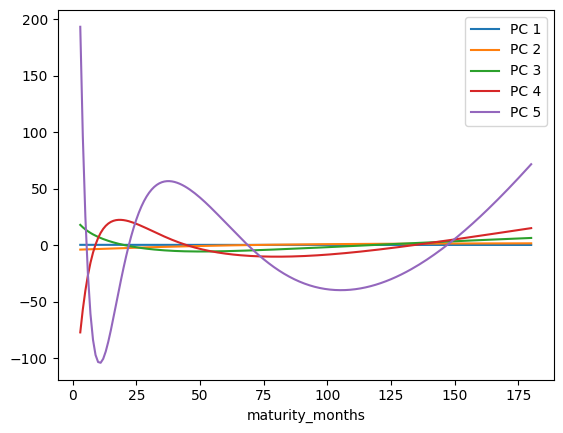

In [417]:
df_loadings.plot()

## Excess returns

Сначала код строит лог-цены:

$$
p_t^{(n)} = - \frac{n}{12} y_t^{(n)}
$$

Затем вычисляет excess return на облигации со сроком $n$ как доходность от удержания ее один период минус короткая ставка:

$$
rx_{t+1}^{(n)} = p_{t+1}^{(n-1)} - p_t^{(n)} - r_t^{(1)}
$$

Соответствие переменных:
- `ttm = np.arange(1, self.n + 1) / 12` это множитель $n/12$;
- `log_prices = - self.curve_monthly * ttm` это $p_t^{(n)}$;
- `shift(-1, axis=1)` сдвигает срок с $n$ на $n-1$;
- `rf = self.short_rate_proxy.shift(1)` это лаг короткой ставки.

Отдельно код принудительно ставит `rx[1] = 0`, потому что для 1M excess return не используется как обычная доходность более длинного бонда.


In [418]:
n = yield_curve.shape[1]
t_m = yield_curve.shape[0]
ttm = np.arange(1, n + 1) / 12
log_prices = - yield_curve * ttm
rf = short_rate.shift(1)
rx = (log_prices - log_prices.shift(1, axis=0).shift(-1, axis=1)).subtract(rf, axis=0)
rx = rx.shift(1, axis=1)

rx = rx.dropna(how='all', axis=0)
rx[1] = 0
rx

maturity_months,1,2,3,4,5,6,7,8,9,10,...,171,172,173,174,175,176,177,178,179,180
date,,,,,,,,,,,,,,,,,,,,,
2015-02-28,0,0.001528,0.003056,0.004584,0.006111,0.007638,0.009165,0.010693,0.012220,0.013745,...,0.132266,0.132652,0.133040,0.133430,0.133822,0.134215,0.134610,0.135007,0.135406,0.135806
2015-03-31,0,0.000189,0.000399,0.000625,0.000863,0.001115,0.001387,0.001684,0.002012,0.002376,...,-0.072380,-0.073265,-0.074147,-0.075025,-0.075899,-0.076770,-0.077637,-0.078500,-0.079360,-0.080215
2015-04-30,0,0.000596,0.001241,0.001942,0.002704,0.003527,0.004414,0.005363,0.006372,0.007438,...,0.176553,0.177225,0.177895,0.178563,0.179230,0.179895,0.180558,0.181221,0.181882,0.182541
2015-05-31,0,0.001055,0.002104,0.003136,0.004139,0.005106,0.006033,0.006917,0.007756,0.008549,...,0.060571,0.060624,0.060675,0.060722,0.060766,0.060807,0.060845,0.060879,0.060911,0.060940
2015-06-30,0,-0.000008,-0.000021,-0.000040,-0.000069,-0.000110,-0.000167,-0.000242,-0.000338,-0.000456,...,-0.041500,-0.041567,-0.041630,-0.041692,-0.041750,-0.041807,-0.041860,-0.041912,-0.041961,-0.042008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-31,0,0.000162,-0.000177,-0.000831,-0.001670,-0.002605,-0.003573,-0.004533,-0.005457,-0.006327,...,0.014045,0.013649,0.013247,0.012836,0.012419,0.011994,0.011562,0.011123,0.010676,0.010223
2024-02-29,0,-0.000399,-0.000822,-0.001264,-0.001724,-0.002197,-0.002679,-0.003163,-0.003644,-0.004116,...,-0.060436,-0.061451,-0.062478,-0.063517,-0.064567,-0.065629,-0.066703,-0.067789,-0.068886,-0.069994
2024-03-31,0,-0.000683,-0.001332,-0.001953,-0.002547,-0.003119,-0.003666,-0.004187,-0.004680,-0.005141,...,-0.107093,-0.107413,-0.107724,-0.108024,-0.108314,-0.108595,-0.108865,-0.109126,-0.109376,-0.109616


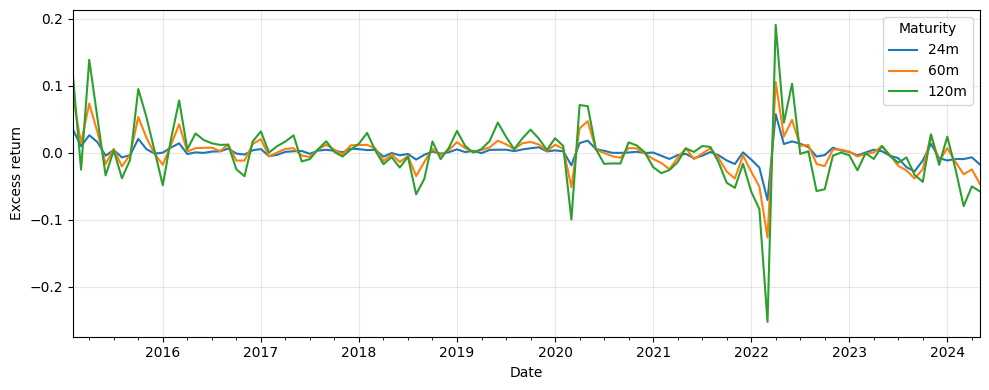

In [419]:
fig, ax = plt.subplots(figsize=(10, 4))

rx[24].plot(ax=ax, label="24m")
rx[60].plot(ax=ax, label="60m")
rx[120].plot(ax=ax, label="120m")

ax.set_xlabel("Date")
ax.set_ylabel("Excess return")
ax.legend(title="Maturity")
ax.grid(True, alpha=0.3)
plt.tight_layout()

## VAR(1) для факторного состояния

Факторная динамика задается как

$$
X_{t+1} = \mu + \Phi X_t + v_{t+1}, \qquad v_{t+1} \sim (0, \Sigma)
$$

В коде:
- `X_lhs` это $X_{t+1}$;
- `X_rhs` это константа и $X_t$;
- `var_coeffs = X_lhs @ pinv(X_rhs)` это OLS-оценка матрицы коэффициентов.
- в коде `mu` зануляется

In [420]:
X = df_pc_m.T
X_lhs = X.values[:, 1:]  # X_t+1. Left hand side of VAR
X_rhs = np.vstack((np.ones((1, t_m-1)), X.values[:, 0:-1]))  # X_t and a constant.

var_coeffs = (X_lhs @ np.linalg.pinv(X_rhs))

phi = var_coeffs[:, 1:]

# Leave the estimated constant
# mu = var_coeffs[:, [0]]

# Force constant to zero
mu = np.zeros((N_FACTORS, 1))
var_coeffs[:, [0]] = 0

# Residuals
v = X_lhs - var_coeffs @ X_rhs
Sigma = v @ v.T / (t_m - 1)

s0 = np.cov(v).reshape((-1, 1))

In [421]:
from statsmodels.tsa.api import VAR
X_var = df_pc_m.copy()
fit = VAR(X_var).fit(maxlags=1, ic=None, trend='c')
fit.coefs[0], var_coeffs[:, 1:]

/Users/codebuller/Desktop/term_rate/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


(array([[ 0.9629237 ,  0.04694927,  0.01152485,  0.05321075,  0.02851903],
        [-0.00637725,  0.93646534,  0.02963739, -0.05429524, -0.00436355],
        [ 0.09374748, -0.02984455,  0.76887237,  0.05027773, -0.00821242],
        [ 0.00272169,  0.04342933, -0.06170963,  0.69190045,  0.20435106],
        [ 0.03032672, -0.06744668,  0.28717073, -0.07481827,  0.51015034]]),
 array([[ 0.9629237 ,  0.04694927,  0.01152485,  0.05321075,  0.02851903],
        [-0.00637725,  0.93646534,  0.02963739, -0.05429524, -0.00436355],
        [ 0.09374748, -0.02984455,  0.76887237,  0.05027773, -0.00821242],
        [ 0.00272169,  0.04342933, -0.06170963,  0.69190045,  0.20435106],
        [ 0.03032672, -0.06744668,  0.28717073, -0.07481827,  0.51015034]]))

## Регрессия excess returns

На втором шаге ACM используется регрессия вида

$$
rx_{t+1}^{(n)} = a_n + c_n' X_t + \beta_n' v_{t+1} + e_{t+1}^{(n)}
$$

В коде матрица регрессоров `Z` содержит:
- константу;
- лагированное состояние `X`;
- инновации VAR `self.v`.

После оценки:
- `beta` это коэффициенты на `v_{t+1}`;
- `omega` это ковариация ошибок $e_{t+1}^{(n)}$;
- `beta_star[i, :] = kron(beta[i, :], beta[i, :])` нужен позже для convexity adjustment.


In [422]:
Z = np.vstack((np.ones((1, t_m-1)), X.values[:, :-1], v)).T  # Lagged X and Innovations
abc = inv(Z.T @ Z) @ (Z.T @ rx.values)
E = rx.values - Z @ abc
omega = np.var(E.reshape(-1, 1)) * np.eye(len(months))

abc = abc.T
beta = abc[:, -N_FACTORS:]

beta_star = np.zeros((len(months), N_FACTORS**2))

for i in range(len(months)):
    beta_star[i, :] = np.kron(beta[i, :], beta[i, :]).T

## Восстановление prices of risk

Это центральный шаг ACM.

Сначала берутся те же excess returns, что и на шаге 5, и добавляется convexity adjustment:

$$
rx_{t+1}^{(n)} + \frac{1}{2}\big(\beta_n^* s_0 + \omega_n\big)
$$

В коде это строка

$$
\texttt{adjustment = beta\_star @ s0 + diag(omega)}
$$

Дальше решается линейная система на $(\lambda_0, \lambda_1)$:

$$
\mathbb E_t[rx_{t+1}^{(n)}] = \beta_n' \lambda_0 + \beta_n' \lambda_1 X_t - \frac{1}{2}\text{adj}_n
$$

В коде:
- `Y` это already adjusted expected returns;
- `X = self.beta` это матрица экспозиций на shocks;
- `Lambda = inv(X.T @ X) @ X.T @ Y` дает `lambda0` и `lambda1`.

После этого код сразу строит risk-neutral динамику факторов:

$$
\mu^* = \mu - \lambda_0, \qquad \Phi^* = \Phi - \lambda_1
$$


In [423]:
factors = np.hstack([np.ones((t_m-1, 1)), df_pc_m.iloc[:-1].values])

# Orthogonalize factors with respect to v
v_proj = v.T @ np.linalg.pinv(v @ v.T) @ v
factors = factors - v_proj @ factors

adjustment = beta_star @ s0 + np.diag(omega).reshape(-1, 1)
rx_adjusted = rx.values + (1 / 2) * np.tile(adjustment, (1, t_m-1)).T
Y = (inv(factors.T @ factors) @ factors.T @ rx_adjusted).T

# Compute Lambda
X = beta
Lambda = inv(X.T @ X) @ X.T @ Y
lambda0 = Lambda[:, 0]
lambda1 = Lambda[:, 1:]

muStar = mu.reshape(-1) - lambda0
phiStar = phi - lambda1

lambda_table = pd.DataFrame(
    data = np.column_stack((lambda0.reshape(-1,1), lambda1)),
    columns = ["lambda0"] + [f"lambda1_{i+1}" for i in range(lambda1.shape[1])]
)
lambda_table.index = [f"Factor {i+1}" for i in range(lambda_table.shape[0])]

print("Lambdas (Market Prices of Risk):")
print(lambda_table)

Lambdas (Market Prices of Risk):
           lambda0  lambda1_1  lambda1_2  lambda1_3  lambda1_4  lambda1_5
Factor 1 -0.009658  -0.032302   0.036338   0.020127   0.045921   0.030922
Factor 2 -0.006182  -0.010015  -0.043848  -0.024045  -0.012796  -0.019579
Factor 3 -0.005328   0.086154  -0.016803  -0.160669  -0.051140   0.029115
Factor 4 -0.006541   0.024973   0.042808  -0.159538  -0.175469   0.099411
Factor 5 -0.068864  -0.030654  -0.079156   0.318048   0.147429  -0.439412


## Short-rate equation

Короткая ставка аппроксимируется линейным уравнением по факторам:

$$
r_t^{(1)} = \delta_0 + \delta_1' X_t
$$

В коде:
- `r1` это уже подготовленная `short_rate_proxy`;
- `add_constant(X)` добавляет свободный член;
- `Delta = inv(X.T @ X) @ X.T @ r1` это OLS-оценка.


In [424]:
r1 = short_rate.reindex(df_pc_m.index)
X = add_constant(df_pc_m)
Delta = inv(X.T @ X) @ X.T @ r1
delta0 = Delta.iloc[0]
delta1 = Delta.iloc[1:].values
# delta1 = np.array([ 2.43224925e-03, -9.07555922e-04,  3.05279642e-04, -9.11157324e-05,
#          2.48474905e-05])
delta0, delta1

(np.float64(0.006578751498548179),
 array([ 0.00195005, -0.0007609 ,  0.00052203, -0.00039057,  0.00012697]))

## Affine recursion

После получения $(\delta_0, \delta_1)$ и $(\lambda_0, \lambda_1)$ код строит affine coefficients рекурсией.

Для первого срока:

$$
A_1 = -\delta_0, \qquad B_1 = -\delta_1
$$

Для следующих сроков:

$$
A_{n+1} = A_n + B_n'(\mu - \lambda_0) + \frac{1}{2}(B_n' \Sigma B_n + \omega) + A_1
$$

$$
B_{n+1} = B_n'(\Phi - \lambda_1) + B_1
$$

В коде:
- `Bpb = np.kron(B[n - 1, :], B[n - 1, :])` это способ записать квадратичный член;
- `s0term` это convexity part;
- один и тот же метод вызывается и для physical measure, и для risk-neutral measure.


In [425]:
def affine_coefficients( lambda0, lambda1):
        lambda0 = lambda0.reshape(-1, 1)
        n = yield_curve.shape[1]
        A = np.zeros(n)
        B = np.zeros((n, N_FACTORS))

        A[0] = - delta0
        B[0, :] = - delta1

        for n in range(1, n):
            Bpb = np.kron(B[n - 1, :], B[n - 1, :])
            s0term = 0.5 * (Bpb @ s0 + omega[0, 0])

            A[n] = (A[n - 1] + B[n - 1, :] @ (mu - lambda0) + s0term + A[0])[0]
            B[n, :] = B[n - 1, :] @ (phi - lambda1) + B[0, :]

        return A, B

In [426]:
# Affine Yield Coefficients
A, B = affine_coefficients(
            lambda0=lambda0,
            lambda1=lambda1,
        )

# Risk-Neutral Coefficients
Arn, Brn = affine_coefficients(
    lambda0=np.zeros(lambda0.shape),
    lambda1=np.zeros(lambda1.shape),
)

In [427]:
def compute_yields( A, B):
        A = A.reshape(-1, 1)
        multiplier = np.tile(yield_curve.columns / 12, (t_m, 1)).T
        yields = (- ((np.tile(A, (1,t_m)) + B @ df_pc_m.T) / multiplier).T).values
        yields = pd.DataFrame(
            data=yields,
            index=yield_curve.index,
            columns=yield_curve.columns,
        )
        return yields

In [428]:
# Model Implied Yield
miy = compute_yields(A, B)

# Risk Neutral Yield
rny = compute_yields(Arn, Brn)

tp = miy - rny

In [429]:
TENORS = {
    "1Y": 12,
    "5Y": 60,
    "10Y": 120,
}
rows = {}

for label, tenor in TENORS.items():
    tmp = pd.concat(
        [
            yield_curve[tenor].rename("obs_log"),
            miy[tenor].rename("fit_log"),
        ],
        axis=1,
    ).dropna()

    obs_pct = np.expm1(tmp["obs_log"]) * 100
    fit_pct = np.expm1(tmp["fit_log"]) * 100
    err = fit_pct - obs_pct

    rows[label] = {
        "RMSE": np.sqrt(np.mean(err**2)),
        "MAE": np.mean(np.abs(err)),
        "Obs.": len(tmp),
    }   

table_pca5 = pd.DataFrame(rows).loc[["RMSE", "MAE", "Obs."]]
print(f'PCA({N_FACTORS})')
table_pca5

PCA(5)


,1Y,5Y,10Y
RMSE,0.029993,0.032833,0.027083
MAE,0.023048,0.021202,0.017764
Obs.,113.000000,113.000000,113.000000


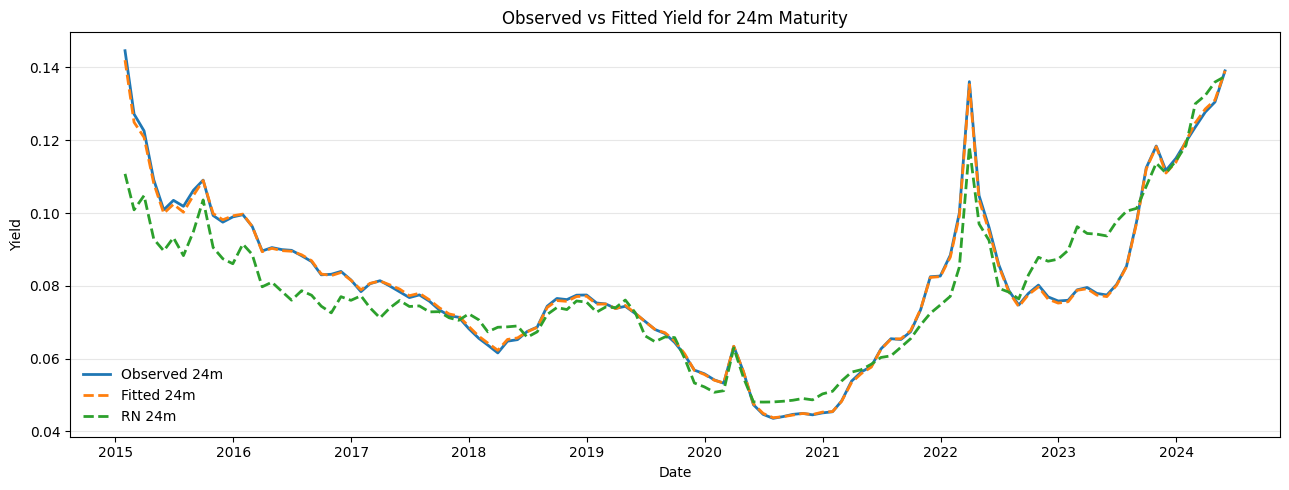

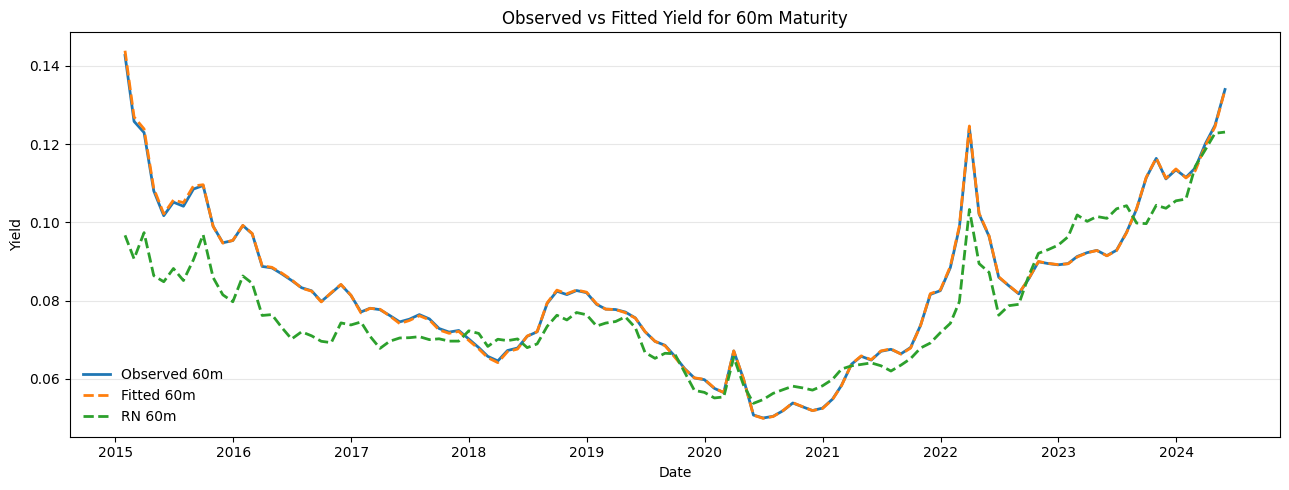

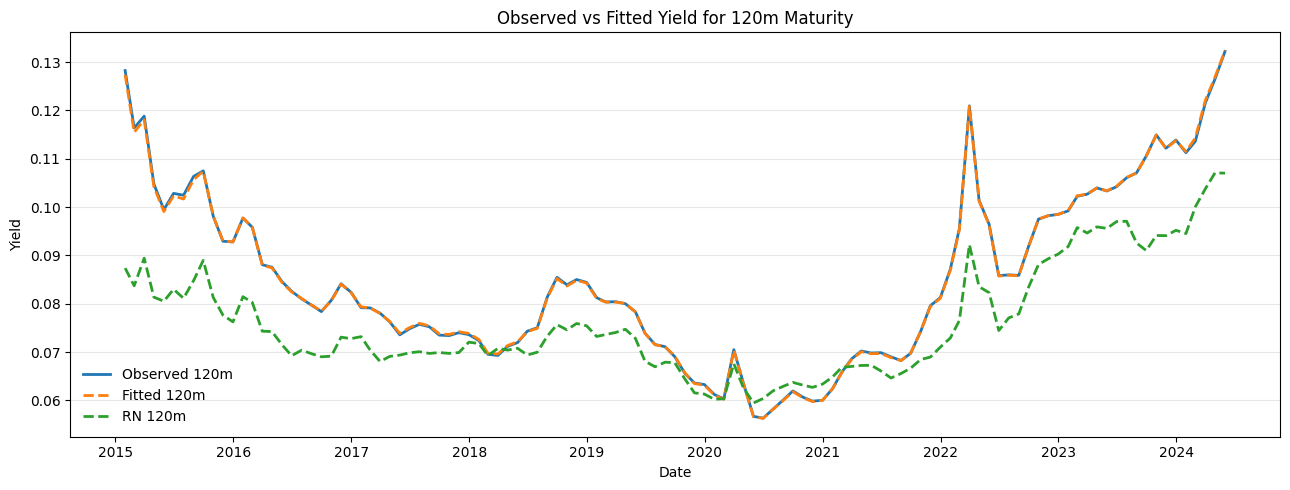

In [430]:
# Chart: Observed vs Fitted (Model Implied Yield)
VISUALIZE_TENORS = [24, 60, 120]

for tenor in VISUALIZE_TENORS:
    fig, ax = plt.subplots(figsize=(13, 5))
    # Plot observed yield
    ax.plot(yield_curve.index, yield_curve[tenor], label=f"Observed {tenor}m", linewidth=2)
    # Plot fitted/model-implied yield
    ax.plot(miy.index, miy[tenor], label=f"Fitted {tenor}m", linewidth=2, linestyle="--")
    ax.plot(rny.index, rny[tenor], label=f"RN {tenor}m", linewidth=2, linestyle="--")
    ax.set_title(f"Observed vs Fitted Yield for {tenor}m Maturity")
    ax.set_ylabel("Yield")
    ax.set_xlabel("Date")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

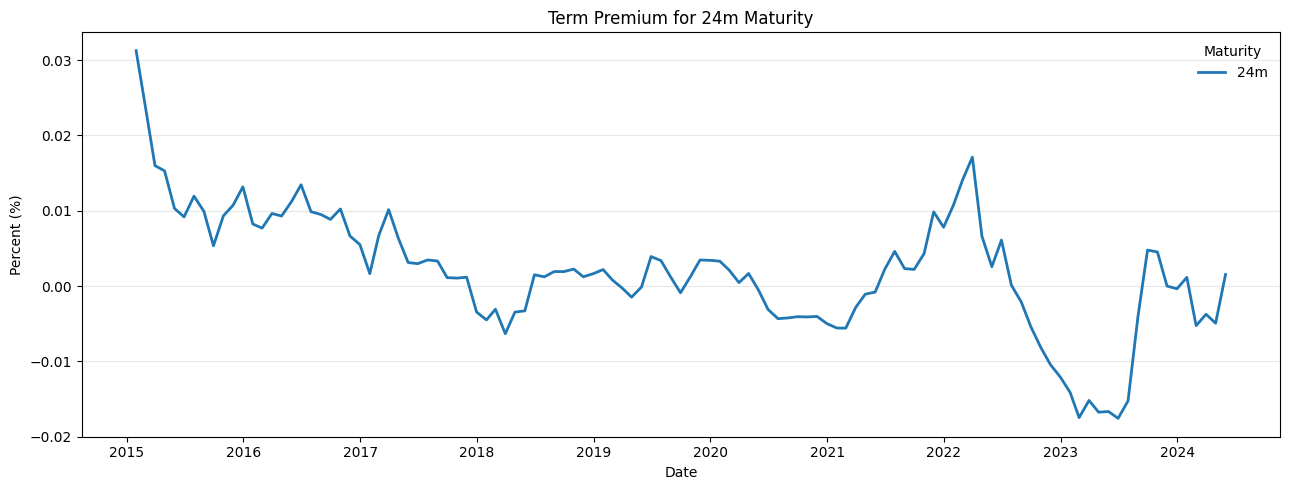

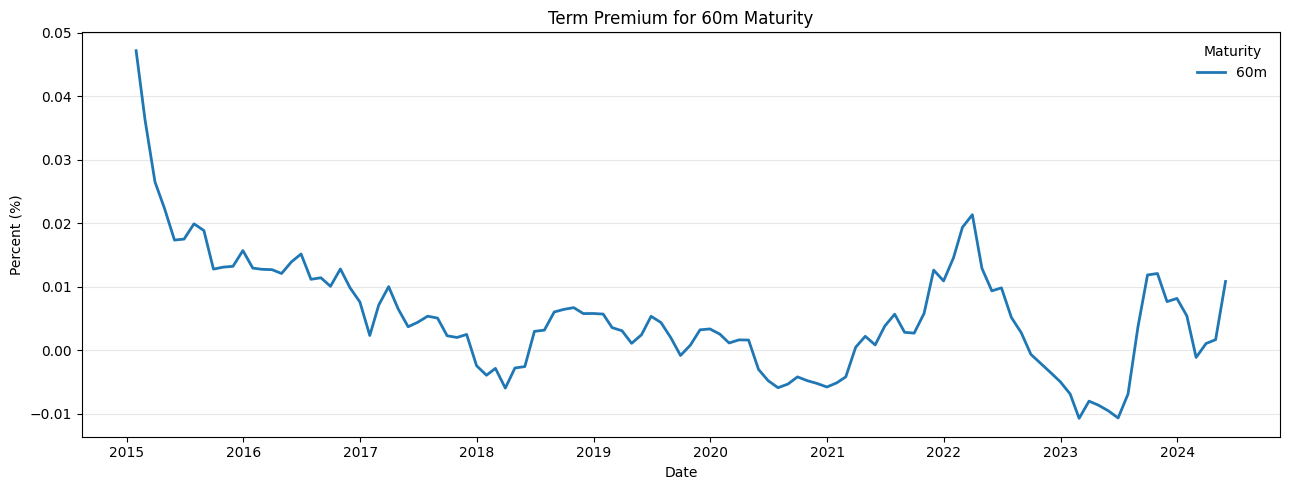

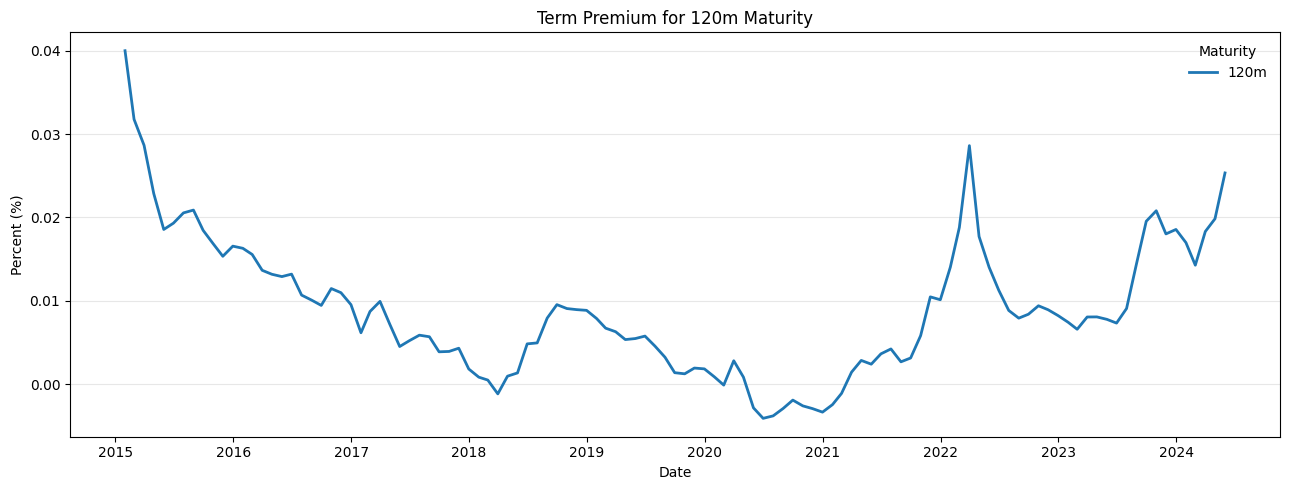

In [ ]:
VISUALIZE_TENORS = [24, 60, 120]

# Make one chart per maturity
for tenor in VISUALIZE_TENORS:
    fig, ax = plt.subplots(figsize=(13, 5))
    # Plot in percent, not decimals
    ax.plot(tp.index, tp[tenor], label=f"{tenor}m", linewidth=2)
    ax.set_title(f"Term Premium for {tenor}m Maturity")
    ax.set_ylabel("Percent (%)")
    ax.set_xlabel("Date")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(title="Maturity", frameon=False)
    plt.tight_layout()
    plt.show()

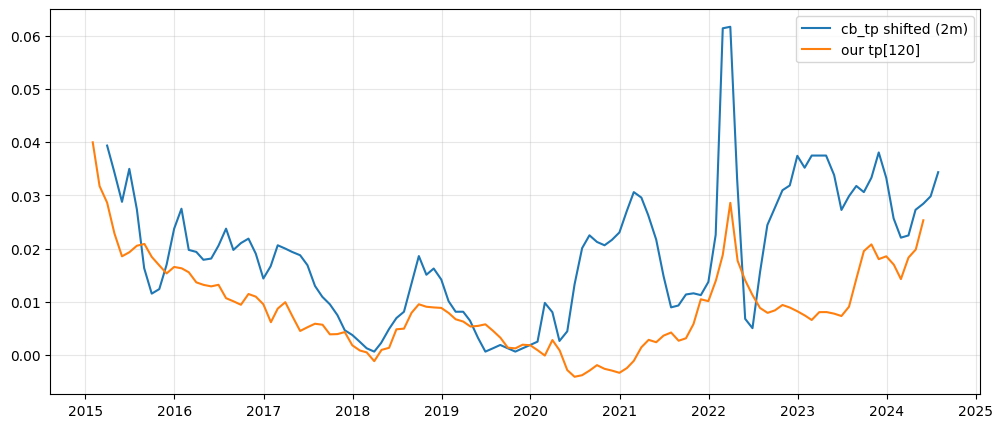

corr: 0.5579529598425774


In [432]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

SHIFT_MONTHS = 2     # > 0 = сдвиг вправо, < 0 = влево

cb_tp = (
    pd.read_csv(Path("cb_tp/output/cb_tp_digitized_monthly.csv"), parse_dates=["date"])
    .loc[lambda df: df["tenor_years"] == 10, ["date", "tp"]]
    .rename(columns={"tp": "cb_tp"})
    .set_index("date")
)

cb_tp_shifted = cb_tp.copy()
cb_tp_shifted.index = cb_tp_shifted.index + pd.DateOffset(months=SHIFT_MONTHS)

plt.figure(figsize=(12, 5))
plt.plot(cb_tp_shifted.index, cb_tp_shifted["cb_tp"] / 100, label=f"cb_tp shifted ({SHIFT_MONTHS}m)")
plt.plot(tp.index, tp[120], label="our tp[120]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

corr = cb_tp_shifted["cb_tp"].corr((tp[120]))
print("corr:", corr)
